In [1]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 1/cleaned_email_data.csv')

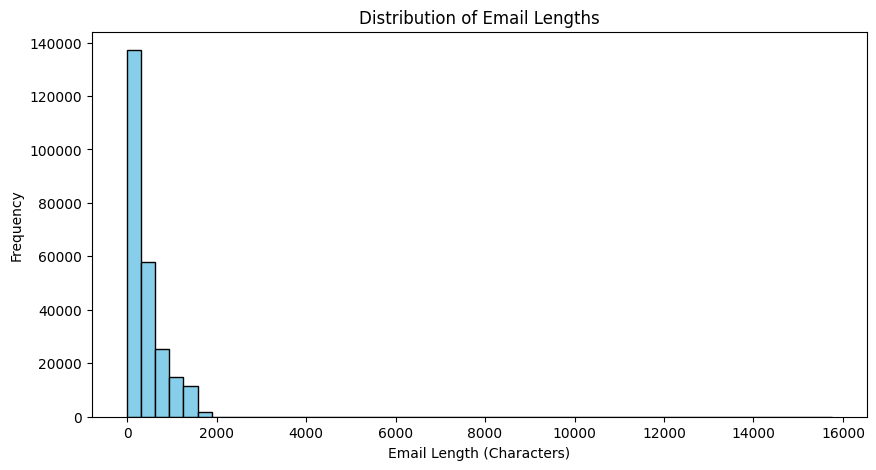

email_length
175     1741
112      863
50       717
184      702
121      664
        ... 
1790       1
2057       1
1772       1
1823       1
8613       1
Name: count, Length: 1875, dtype: int64

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate email lengths
email_data["email_length"] = email_data["Combined_Text"].str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(email_data["email_length"], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Email Length (Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Email Lengths")
plt.show()

email_data["email_length"].value_counts()


In [2]:
total_rows = len(email_data)
print(f"Total rows: {total_rows}")

Total rows: 248819


In [5]:
num_rows = (email_data["email_length"] > 500).sum()

print(f"Number of emails longer than 500 characters: {num_rows}")

Number of emails longer than 500 characters: 72342


In [6]:
email_data = email_data[email_data["email_length"] <= 500]

In [7]:
total_rows = len(email_data)
print(f"Total rows: {total_rows}")

Total rows: 176477


In [8]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time',
       'Response Time', 'Extracted Metadata', 'url_count',
       'email_address_count', 'attachment_count', 'Cleaned_Subject',
       'Cleaned_Message', 'Combined_Text', 'email_length'],
      dtype='object')

In [9]:
#email_data = email_data.drop(columns=["From"])
#email_data = email_data.drop(columns=["To"])
email_data = email_data.drop(columns=["Response Time"])
email_data = email_data.drop(columns=["Extracted Metadata"])
email_data = email_data.drop(columns=["email_address_count"])
email_data = email_data.drop(columns=["attachment_count"])
email_data = email_data.drop(columns=["email_length"])

In [10]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text'],
      dtype='object')

In [11]:
total_rows = len(email_data)
print(f"Total rows: {total_rows}")

Total rows: 176477


In [13]:
import pandas as pd
import re
from bs4 import BeautifulSoup

def clean_email_data(email_data):
    """
    Function to clean 'Subject' and 'Message' columns:
    - Strips leading/trailing spaces
    - Removes special characters and symbols
    - Removes HTML tags
    - Stores cleaned versions in new columns 'Subject_LLM' and 'Message_LLM'
    """
    
    def clean_text(text):
        """
        Helper function to clean the text by:
        - Stripping leading/trailing spaces
        - Removing special characters and symbols
        - Removing HTML tags
        - Handling non-string values
        """
        if not isinstance(text, str):  # Ensure the text is a string
            text = str(text) if text is not None else ""  # Convert non-string to an empty string if None

        # Step 1: Remove HTML tags
        text = BeautifulSoup(text, "html.parser").get_text()

        # Step 2: Remove special characters or symbols (allow letters, numbers, and spaces)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

        # Step 3: Strip leading and trailing spaces
        text = text.strip()

        return text

    # Step 1: Clean 'Subject' and 'Message' columns and store the cleaned text in new columns
    email_data['Subject_LLM'] = email_data['Subject'].apply(clean_text)
    email_data['Message_LLM'] = email_data['Message'].apply(clean_text)

    return email_data

# Clean the email data
email_data_cleaned = clean_email_data(email_data)

C:\Users\User\AppData\Local\Temp\ipykernel_27616\1068849092.py:26: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()
C:\Users\User\AppData\Local\Temp\ipykernel_27616\1068849092.py:26: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()
C:\Users\User\AppData\Local\Temp\ipykernel_27616\1068849092.py:26: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()


In [ ]:
email_data

In [14]:
import pandas as pd

batch_size = 20000  # Number of rows per file

# Loop to create and save batches
for i in range(0, len(email_data), batch_size):
    batch = email_data.iloc[i:i + batch_size]  # Get the batch
    batch.to_csv(f"email_batch_{i//batch_size + 1}.csv", index=False)  # Save to CSV

print("Files saved successfully!")

Files saved successfully!
